In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 14)


,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [4]:
df.groupby('remote_type')['salary_min_usd'].mean()

remote_type
Hybrid    101162.023552
Onsite    100542.713629
Remote    100901.839422
Name: salary_min_usd, dtype: float64

In [5]:
remote_salary = df[df['remote_type'] == 'Remote']['salary_min_usd']

onsite_salary = df[df['remote_type'] == 'Onsite']['salary_min_usd']

print("Remote jobs:", len(remote_salary))
print("Onsite jobs:", len(onsite_salary))

Remote jobs: 16478
Onsite jobs: 16538


In [6]:
t_stat, p_value = stats.ttest_ind(
    remote_salary,
    onsite_salary
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.8805717162393707
P-value: 0.37855608289430576


In [7]:
if p_value < 0.05:
    print("Statistically significant difference exists.")
else:
    print("No statistically significant difference exists.")

No statistically significant difference exists.


# T-Test Analysis

Objective:
Compare salaries between Remote and Onsite jobs.

Null Hypothesis (H0):
There is no significant salary difference between Remote and Onsite jobs.

Alternative Hypothesis (H1):
There is a significant salary difference between Remote and Onsite jobs.

Decision:
Based on the p-value obtained from the t-test.

In [8]:
remote_salary = df[df['remote_type'] == 'Remote']['salary_min_usd']

hybrid_salary = df[df['remote_type'] == 'Hybrid']['salary_min_usd']

onsite_salary = df[df['remote_type'] == 'Onsite']['salary_min_usd']

In [9]:
f_stat, p_value = stats.f_oneway(
    remote_salary,
    hybrid_salary,
    onsite_salary
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.1792861227878717
P-value: 0.3075067294271892


In [10]:
if p_value < 0.05:
    print("At least one group mean differs significantly.")
else:
    print("No statistically significant difference among groups.")

No statistically significant difference among groups.


# ANOVA Analysis

Objective:
Compare salaries across Remote, Hybrid and Onsite jobs.

Null Hypothesis (H0):
Average salary is equal across all remote types.

Alternative Hypothesis (H1):
At least one remote type has a different average salary.

Decision:
Based on ANOVA p-value.

In [11]:
contingency_table = pd.crosstab(
    df['experience_level'],
    df['remote_type']
)

contingency_table

remote_type,Hybrid,Onsite,Remote
experience_level,,,
Entry,5579,5591,5458
Mid,5693,5480,5522
Senior,5712,5467,5498


In [12]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 3.7536175042305726
P-value: 0.44037565959648006
Degrees of Freedom: 4


In [13]:
if p_value < 0.05:
    print("Variables are significantly associated.")
else:
    print("No significant association detected.")

No significant association detected.


# Chi-Square Analysis

Objective:
Determine whether experience level and remote type are associated.

Null Hypothesis (H0):
Experience level and remote type are independent.

Alternative Hypothesis (H1):
Experience level and remote type are associated.

Decision:
Based on Chi-square p-value.

In [14]:
year_counts = df['posted_year'].value_counts().sort_index()

year_counts

posted_year
2020    7205
2021    7128
2022    7135
2023    7035
2024    7312
2025    7043
2026    7142
Name: count, dtype: int64

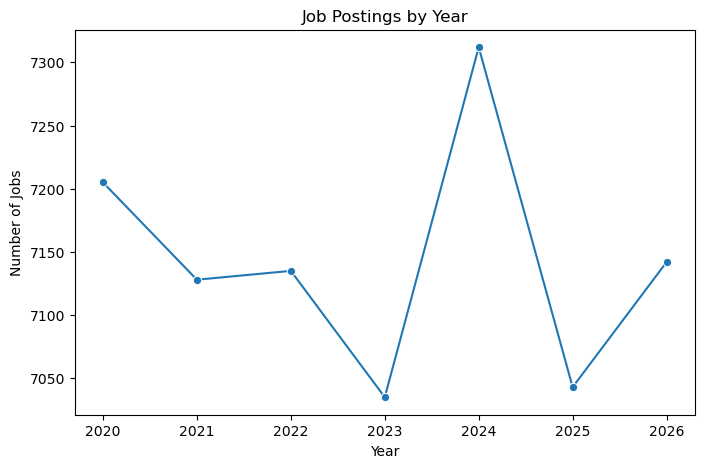

In [15]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o'
)

plt.title("Job Postings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Jobs")

plt.savefig(
    "../reports/figures/job_postings_trend.png",
    bbox_inches="tight"
)

plt.show()

# Time-Based EDA

Objective:

Analyze trends in job postings across years.

Observation:

The trend line illustrates the distribution of job postings from 2020 to 2026.

This helps identify whether AI/Data Science hiring activity increased or decreased over time.

In [16]:
df['average_salary'] = (
    df['salary_min_usd'] +
    df['salary_max_usd']
) / 2

df[['salary_min_usd','salary_max_usd','average_salary']].head()

,salary_min_usd,salary_max_usd,average_salary
0,56873,72223,64548.0
1,54803,85599,70201.0
2,149980,175806,162893.0
3,53483,86477,69980.0
4,102977,127298,115137.5


In [17]:
df['salary_range'] = (
    df['salary_max_usd'] -
    df['salary_min_usd']
)

df[['salary_min_usd','salary_max_usd','salary_range']].head()

,salary_min_usd,salary_max_usd,salary_range
0,56873,72223,15350
1,54803,85599,30796
2,149980,175806,25826
3,53483,86477,32994
4,102977,127298,24321


In [18]:
df['experience_category'] = np.where(
    df['min_experience_years'] <= 2,
    'Junior',
    'Experienced'
)

df['experience_category'].value_counts()

experience_category
Junior         33323
Experienced    16677
Name: count, dtype: int64

In [19]:
df['remote_flag'] = np.where(
    df['remote_type'] == 'Remote',
    1,
    0
)

df['remote_flag'].value_counts()

remote_flag
0    33522
1    16478
Name: count, dtype: int64

In [20]:
salary_threshold = df['average_salary'].median()

salary_threshold

107565.25

In [21]:
df['high_salary_job'] = np.where(
    df['average_salary'] > salary_threshold,
    1,
    0
)

df['high_salary_job'].value_counts()

high_salary_job
0    25000
1    25000
Name: count, dtype: int64

In [22]:
CURRENT_YEAR = 2026

df['job_age'] = CURRENT_YEAR - df['posted_year']

df[['posted_year','job_age']].head()

,posted_year,job_age
0,2023,3
1,2024,2
2,2021,5
3,2023,3
4,2023,3


In [23]:
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,average_salary,salary_range,experience_category,remote_flag,high_salary_job,job_age
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0,15350,Junior,1,0,3
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0,30796,Junior,1,0,2
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0,25826,Experienced,1,1,5
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0,32994,Junior,1,0,3
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5,24321,Junior,0,1,3


In [24]:
df.to_csv(
    "../data/processed/final_cleaned_day4.csv",
    index=False
)

print("Final dataset saved successfully")

Final dataset saved successfully


In [25]:
import os

os.path.exists(
    "../data/processed/final_cleaned_day4.csv"
)

True

# Day 4 Summary

## Statistical Tests

- T-Test completed
- ANOVA completed
- Chi-Square test completed

## Time-Based EDA

- Analyzed job posting trends by year

## Feature Engineering

Created the following features:

1. average_salary
2. salary_range
3. experience_category
4. remote_flag
5. high_salary_job
6. job_age

## Output

data/processed/final_cleaned_day4.csv